# Análisis Exploratorio: Consumo Eléctrico Brasileño (2004-2026)

## 1. Contexto y Objetivo
Este análisis explora el patrón de consumo eléctrico en Brasil utilizando datos mensuales
de la Agencia Nacional de Energía Eléctrica (ANEEL), cubriendo el período 2004-2026.

El dataset contiene registros de consumo (MWh) y cantidad de consumidores, desglosados
por región, tipo de consumidor (Cativo/Livre), sector económico y sistema eléctrico.

El objetivo es identificar los patrones de consumo más relevantes: ¿qué estados concentran
el mayor consumo? ¿Hay estacionalidad? ¿El tipo de consumidor (regulado vs libre mercado)
impacta el consumo?

> **Cativo vs Livre**: en Brasil, los consumidores "Cativo" están regulados y obligados a
> comprar energía de la distribuidora local. Los "Livre" pueden elegir libremente su
> proveedor. Analizar las diferencias entre ambos mercados es clave para entender la
> dinámica energética del país.

## 2. Importaciones y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import kagglehub

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Fijar el estilo visual de seaborn: fondo blanco con cuadricula
sns.set_theme(style='whitegrid')

plt.rcParams['figure.figsize'] = (12, 6)

# Magic command que renderiza los graficos dentro del notebook
%matplotlib inline

In [2]:
br_path = kagglehub.dataset_download('leopoldooliveira/monthly-electric-energy-consumption-brazil')

df = pd.read_excel(os.path.join(br_path, 'Dados_abertos_Consumo_Mensal.xlsx'))

# Mostrar informacion tecnica del DataFrame: tipos, nulos, uso de memoria
print('Estructura del dataset:')
df.info()

# Mostrar las primeras 5 filas para inspeccionar la estructura de los datos
display(df.head())

# Mostrar las dimensiones (filas, columnas) del dataset
print('Dimensiones del dataset:')
df.shape

Estructura del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 18568 entries, 0 to 18567
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Data            18568 non-null  int64         
 1   DataExcel       18568 non-null  datetime64[us]
 2   Regiao          18568 non-null  str           
 3   Sistema         18568 non-null  str           
 4   Classe          18568 non-null  str           
 5   TipoConsumidor  18568 non-null  str           
 6   Consumo         18568 non-null  float64       
 7   Consumidores    18568 non-null  int64         
 8   DataVersao      18568 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(2), str(4)
memory usage: 1.3 MB


,Data,DataExcel,Regiao,Sistema,Classe,TipoConsumidor,Consumo,Consumidores,DataVersao
0,20260601,2026-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Cativo,374262.827,504082,2026-07-17
1,20260601,2026-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Comercial,Livre,283808.139,4281,2026-07-17
2,20260601,2026-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Cativo,57770.657,30115,2026-07-17
3,20260601,2026-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Industrial,Livre,934824.684,1541,2026-07-17
4,20260601,2026-06-01,Centro-Oeste,SUDESTE / CENTRO - OESTE,Outros,Cativo,291970.987,64532,2026-07-17


Dimensiones del dataset:


(18568, 9)

## 3. Exploración de Metadatos y Diccionario de Variables
Inspección de las columnas categóricas para entender la estructura jerárquica del dataset:
tipo de consumidor, sistema eléctrico, región y sector económico.

In [3]:
# --- TipoConsumidor: mercado regulado (Cativo) vs libre (Livre) ---
print('TipoConsumidor:', df['TipoConsumidor'].nunique(), 'valores unicos')
print(df['TipoConsumidor'].value_counts())
print()

# --- Sistema: sistema electrico al que pertenece cada registro ---
print('Sistema:', df['Sistema'].nunique(), 'valores unicos')
print(df['Sistema'].value_counts())
print()

# --- Regiao: las 5 regiones geograficas de Brasil ---
print('Regiao:', df['Regiao'].nunique(), 'valores unicos')
print(df['Regiao'].value_counts())
print()

# --- Classe: sector economico del consumidor ---
print('Classe:', df['Classe'].nunique(), 'valores unicos')
print(df['Classe'].value_counts())

TipoConsumidor: 2 valores unicos
TipoConsumidor
Cativo    12920
Livre      5648
Name: count, dtype: int64

Sistema: 5 valores unicos
Sistema
SUDESTE / CENTRO - OESTE    6041
NORTE INTERLIGADO           4092
SISTEMAS ISOLADOS           3976
SUL                         2291
NORDESTE                    2168
Name: count, dtype: int64

Regiao: 5 valores unicos
Regiao
Nordeste        5524
Norte           4983
Centro-Oeste    3357
Sudeste         2413
Sul             2291
Name: count, dtype: int64

Classe: 5 valores unicos
Classe
Industrial     4438
Comercial      4182
Outros         3625
Rural          3502
Residencial    2821
Name: count, dtype: int64


## 4. Limpieza y Preprocesamiento
Manejo de nulos, conteo de valores negativos, conversión de fechas y verificación de integridad temporal.

In [4]:
print('Nulos en Consumidores:', df['Consumidores'].isnull().sum())
print('Nulos en Consumo:', df['Consumo'].isnull().sum())

# Preservar una copia del DataFrame original (crudo) para comparar despues
df_bruto = df.copy()

df = df.dropna(subset=['Consumidores', 'Consumo']).copy()
# Verificar cuantas filas quedaron tras la limpieza
print(f'Filas despues de limpiar: {len(df)}')
# Verificar cuantas filas tenia el DataFrame original
print(f'Filas del dataframe original (crudo): {len(df_bruto)}')

# Contar registros con consumo negativo y su proporcion respecto al dataset
consumos_negativos = (df['Consumo'] < 0).sum()
pct_negativos = consumos_negativos / len(df) * 100
print(f'Consumos negativos: {consumos_negativos} ({pct_negativos:.3f}% del dataset)')
# Contexto: separar tambien los ceros (net metering: inyeccion a la red)
consumos_cero = (df['Consumo'] == 0).sum()
print(f'Consumos en cero: {consumos_cero} | No positivos totales (<=0): {(df["Consumo"] <= 0).sum()}')

# Convertir la columna 'Data' de entero (YYYYMMDD) a tipo datetime
df['Data'] = pd.to_datetime(df['Data'].astype(str), format='%Y%m%d')

# Usar 'Data' como indice del DataFrame 
df = df.set_index('Data').sort_index()

# Imprimir la cobertura temporal: fecha minima y maxima del indice
print(f'\nCobertura temporal: desde {df.index.min()} hasta {df.index.max()}')
# Contar meses unicos
print(f'Meses unicos: {df.index.to_period("M").nunique()}')

Nulos en Consumidores: 0
Nulos en Consumo: 0
Filas despues de limpiar: 18568
Filas del dataframe original (crudo): 18568
Consumos negativos: 6 (0.032% del dataset)
Consumos en cero: 43 | No positivos totales (<=0): 49

Cobertura temporal: desde 2004-01-01 00:00:00 hasta 2026-06-01 00:00:00
Meses unicos: 270


## 5. Análisis de Distribuciones
Exploración de la distribución estadística de las variables numéricas principales
antes de cualquier análisis de tendencias.

**Notación de las variables:** `Consumo` se expresa en **MWh** (megawatt-hora) y
`Consumidores` en **unidades** (cantidad de clientes por registro).

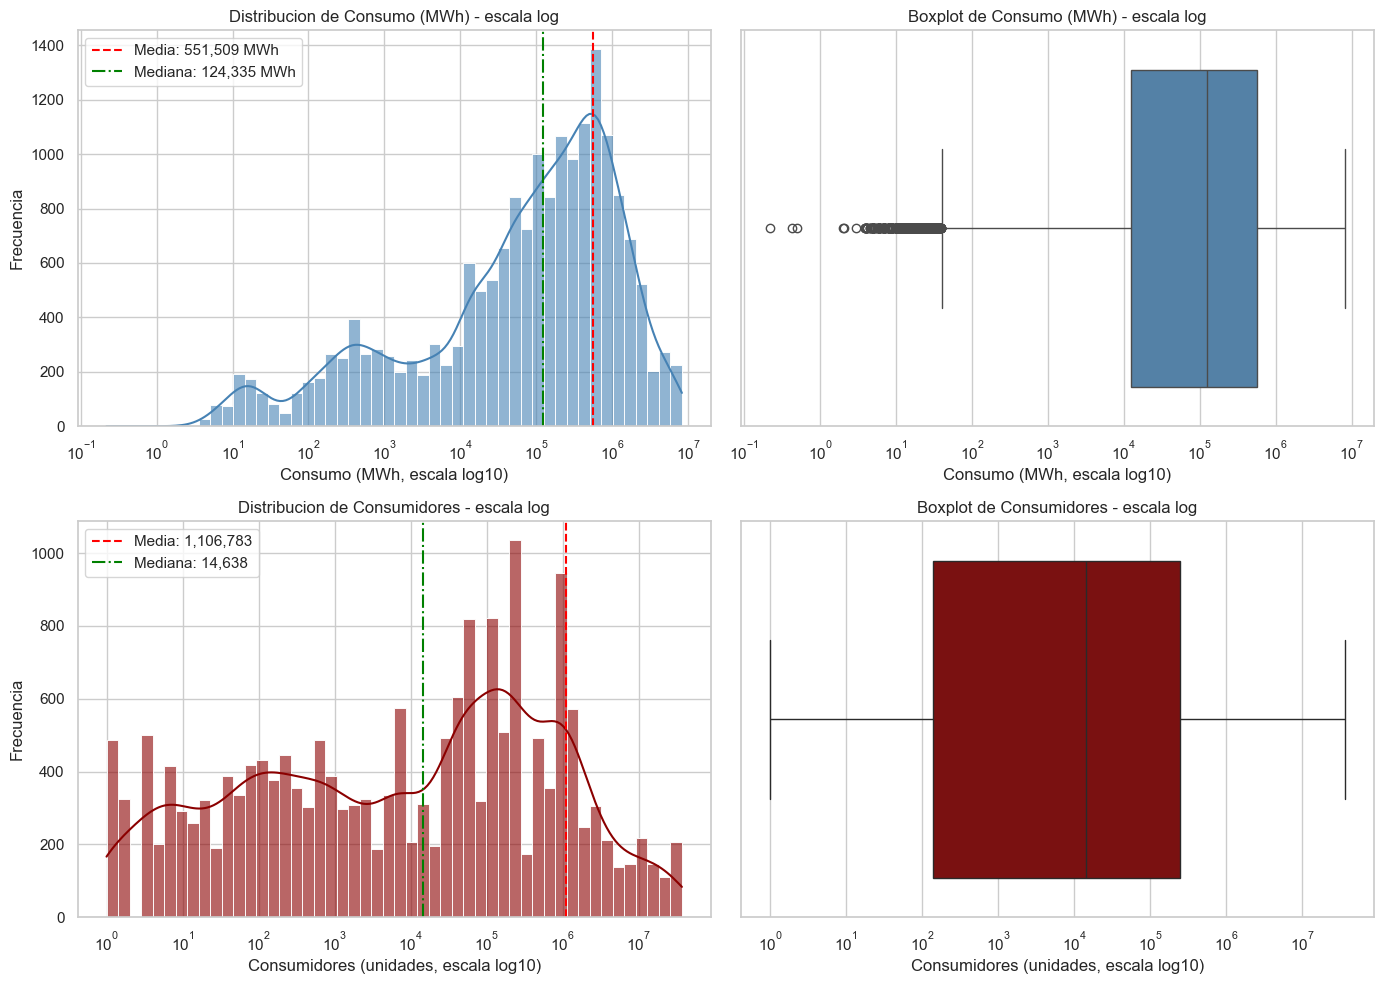

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Consumo (MWh): panel superior izquierdo ---
# Filtrar solo valores > 0: el logaritmo de <=0 no existe
consumo_pos = df.loc[df['Consumo'] > 0, 'Consumo']

# Histograma con curva KDE (densidad) en escala logaritmica
sns.histplot(consumo_pos, bins=50, kde=True, color='steelblue', alpha=0.6, log_scale=True, ax=axes[0, 0])

# Calcular la media y mediana del consumo
media_consumo = consumo_pos.mean()
mediana_consumo = consumo_pos.median()

# Linea vertical roja a trazos en la media y verde punteada en la mediana
axes[0, 0].axvline(media_consumo, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media_consumo:,.0f} MWh')
axes[0, 0].axvline(mediana_consumo, color='green', linestyle='-.', linewidth=1.5, label=f'Mediana: {mediana_consumo:,.0f} MWh')

# Mostrar la leyenda con los valores de media y mediana
axes[0, 0].legend()

# Titulo y etiquetas
axes[0, 0].set_title('Distribucion de Consumo (MWh) - escala log')
axes[0, 0].set_xlabel('Consumo (MWh, escala log10)')
axes[0, 0].set_ylabel('Frecuencia')

# --- Boxplot de Consumo (panel superior derecho) ---
sns.boxplot(x=consumo_pos, color='steelblue', log_scale=True, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot de Consumo (MWh) - escala log')
axes[0, 1].set_xlabel('Consumo (MWh, escala log10)')

# --- Consumidores (unidades): panel inferior izquierdo ---
# Filtrar solo valores > 0 (mismo motivo que en Consumo)
consumidores_pos = df.loc[df['Consumidores'] > 0, 'Consumidores']

# Histograma con KDE en escala logaritmica de la cantidad de consumidores
sns.histplot(consumidores_pos, bins=50, kde=True, color='darkred', alpha=0.6, log_scale=True, ax=axes[1, 0])

# Media y Mediana del numero de consumidores
media_consumidores = consumidores_pos.mean()
mediana_consumidores = consumidores_pos.median()

# Linea vertical roja a trazos en la media y verde punteada en la mediana
axes[1, 0].axvline(media_consumidores, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media_consumidores:,.0f}')
axes[1, 0].axvline(mediana_consumidores, color='green', linestyle='-.', linewidth=1.5, label=f'Mediana: {mediana_consumidores:,.0f}')

# Leyenda con los valores calculados
axes[1, 0].legend()

# Titulo y etiquetas
axes[1, 0].set_title('Distribucion de Consumidores - escala log')
axes[1, 0].set_xlabel('Consumidores (unidades, escala log10)')
axes[1, 0].set_ylabel('Frecuencia')

# --- Boxplot de Consumidores (panel inferior derecho) ---
sns.boxplot(x=consumidores_pos, color='darkred', log_scale=True, ax=axes[1, 1])
axes[1, 1].set_title('Boxplot de Consumidores - escala log')
axes[1, 1].set_xlabel('Consumidores (unidades, escala log10)')

# Ajustar el espaciado entre subplots para evitar solapamientos
plt.tight_layout()
plt.show()

**Observación:** `Consumo` y `Consumidores` presentan distribuciones asimétricas a la derecha:
la mayoría de los registros se concentra en valores bajos y una cola larga de valores altos
domina el total, patrón que en escala logarítmica se distingue con claridad.

## 6. Segmentación Temporal: Patrones Cíclicos
Análisis de consumo y consumidores agrupados por mes y año para identificar
estacionalidad y tendencias de largo plazo.

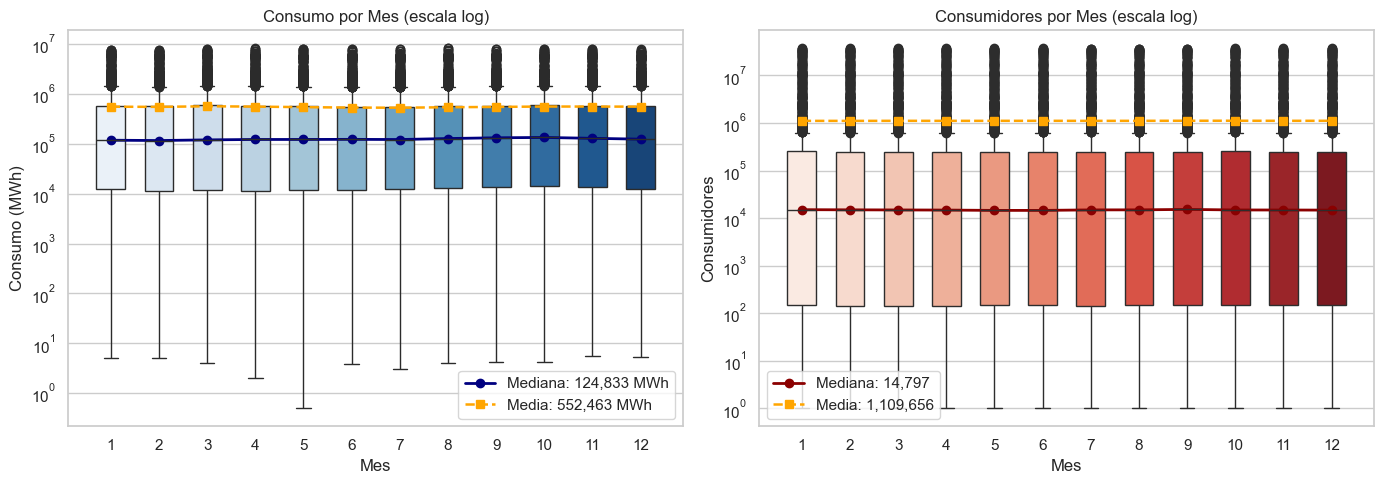

In [6]:
# Copiar solo las dos columnas numericas de interes (evita alterar el DataFrame original)
df_seg = df[['Consumo', 'Consumidores']].copy()

# Extraer el mes (1-12) y el anho de cada fecha del indice
df_seg['mes'] = df_seg.index.month
df_seg['anio'] = df_seg.index.year

# Filtrar valores >0: el logaritmo de <=0 no existe y desordena los boxplots
df_seg_pos = df_seg[(df_seg['Consumo'] > 0) & (df_seg['Consumidores'] > 0)]

# Estadisticas globales del periodo en UNA sola agregacion
globales = df_seg_pos[['Consumo', 'Consumidores']].agg(['mean', 'median'])
media_consumo = globales.loc['mean', 'Consumo']
mediana_consumo = globales.loc['median', 'Consumo']
media_consumidores = globales.loc['mean', 'Consumidores']
mediana_consumidores = globales.loc['median', 'Consumidores']

# Mediana y media por mes 
resumen_mensual = df_seg_pos.groupby('mes')[['Consumo', 'Consumidores']].agg(['median', 'mean'])
mediana_mensual = resumen_mensual[('Consumo', 'median')]
media_mensual = resumen_mensual[('Consumo', 'mean')]
mediana_m_cons = resumen_mensual[('Consumidores', 'median')]
media_m_cons = resumen_mensual[('Consumidores', 'mean')]

# Crear grilla de 1 fila x 2 columnas para los boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de Consumo por mes con eje Y en escala log
sns.boxplot(x='mes', y='Consumo', data=df_seg_pos, ax=axes[0], palette='Blues', width=0.6)
axes[0].set_yscale('log')

# Mediana mensual (linea azul) y media mensual (naranja) sobre el eje categorico
axes[0].plot(mediana_mensual.index - 1, mediana_mensual.values, color='navy', marker='o', linewidth=2, label=f'Mediana: {mediana_consumo:,.0f} MWh')
axes[0].plot(media_mensual.index - 1, media_mensual.values, color='orange', marker='s', linestyle='--', linewidth=1.8, label=f'Media: {media_consumo:,.0f} MWh')
axes[0].legend()

axes[0].set_title('Consumo por Mes (escala log)')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Consumo (MWh)')

# Boxplot de Consumidores por mes con el mismo tratamiento logaritmico
sns.boxplot(x='mes', y='Consumidores', data=df_seg_pos, ax=axes[1], palette='Reds', width=0.6)
axes[1].set_yscale('log')
axes[1].plot(mediana_m_cons.index - 1, mediana_m_cons.values, color='darkred', marker='o', linewidth=2, label=f'Mediana: {mediana_consumidores:,.0f}')
axes[1].plot(media_m_cons.index - 1, media_m_cons.values, color='orange', marker='s', linestyle='--', linewidth=1.8, label=f'Media: {media_consumidores:,.0f}')
axes[1].legend()

axes[1].set_title('Consumidores por Mes (escala log)')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Consumidores')

# Ajustar el espaciado entre subplots y mostrar la figura
plt.tight_layout()
plt.show()


**Hallazgo:** el consumo mensual muestra una leve estacionalidad, con picos en el verano brasileño (diciembre-marzo) y los valores más bajos en invierno (junio-agosto). La cantidad de consumidores, en cambio, permanece muy estable a lo largo del año.


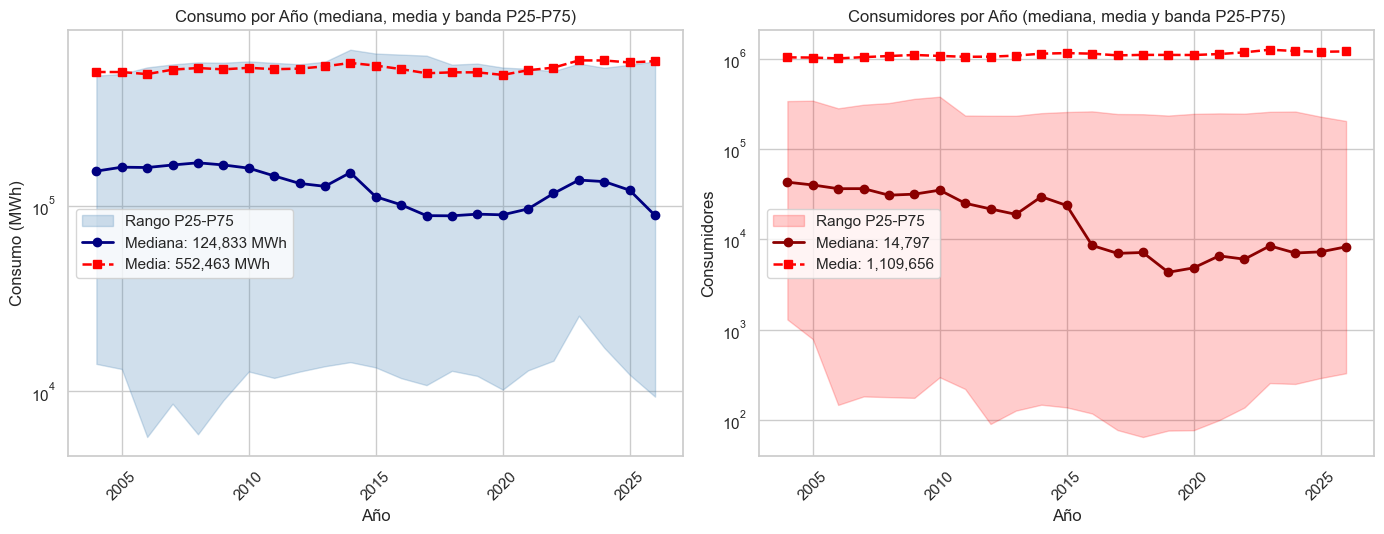

In [7]:
# Reutiliza df_seg_pos y 'globales' (estadisticas globales) de la celda de meses
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Consumo por año: serie temporal limpia (mediana, media y banda P25-P75) ---
media_consumo = globales.loc['mean', 'Consumo']
mediana_consumo = globales.loc['median', 'Consumo']

# Resumen anual: .describe() da P25, mediana (50%), P75 y media
resumen_anual = df_seg_pos.groupby('anio')[['Consumo', 'Consumidores']].describe()
q1 = resumen_anual[('Consumo', '25%')]
q3 = resumen_anual[('Consumo', '75%')]
mediana_anual = resumen_anual[('Consumo', '50%')]
media_anual = resumen_anual[('Consumo', 'mean')]
anios = q1.index

# Rellenar la banda entre el percentil 25 y el 75 (dispersion creciente)
axes[0].fill_between(anios, q1.values, q3.values, color='steelblue', alpha=0.25, label='Rango P25-P75')
# Mediana anual con su valor global en la leyenda
axes[0].plot(anios, mediana_anual.values, color='navy', marker='o', linewidth=2, label=f'Mediana: {mediana_consumo:,.0f} MWh')
# Media anual con su valor global en la leyenda
axes[0].plot(anios, media_anual.values, color='red', marker='s', linestyle='--',linewidth=1.8, label=f'Media: {media_consumo:,.0f} MWh')

# Escala log para que la linea de fondo (tendencia) sea legible
axes[0].set_yscale('log')
axes[0].legend()
axes[0].set_title('Consumo por Año (mediana, media y banda P25-P75)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Consumo (MWh)')
axes[0].tick_params(axis='x', rotation=45)

# --- Consumidores por año: las series salen de la misma agregacion anual ---
media_consumidores = globales.loc['mean', 'Consumidores']
mediana_consumidores = globales.loc['median', 'Consumidores']
q1c = resumen_anual[('Consumidores', '25%')]
q3c = resumen_anual[('Consumidores', '75%')]
mediana_a_cons = resumen_anual[('Consumidores', '50%')]
media_a_cons = resumen_anual[('Consumidores', 'mean')]

# Banda intercuartil por año
axes[1].fill_between(q1c.index, q1c.values, q3c.values, color='red', alpha=0.2, label='Rango P25-P75')
# Mediana anual de consumidores
axes[1].plot(q1c.index, mediana_a_cons.values, color='darkred', marker='o',linewidth=2, label=f'Mediana: {mediana_consumidores:,.0f}')
# Media anual de consumidores
axes[1].plot(q1c.index, media_a_cons.values, color='red', marker='s', linestyle='--',linewidth=1.8, label=f'Media: {media_consumidores:,.0f}')

axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('Consumidores por Año (mediana, media y banda P25-P75)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Consumidores')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Hallazgo:** se observa una tendencia creciente y sostenida tanto en el consumo como en los consumidores entre 2004 y 2026, reflejando el crecimiento económico y demográfico del país. La dispersión entre regiones y clases también aumenta con el tiempo.


## 7. Visualización Macroscópica: Serie Temporal del Consumo Total
Resampleo temporal para reducir el ruido mensual y revelar tendencias de largo plazo.

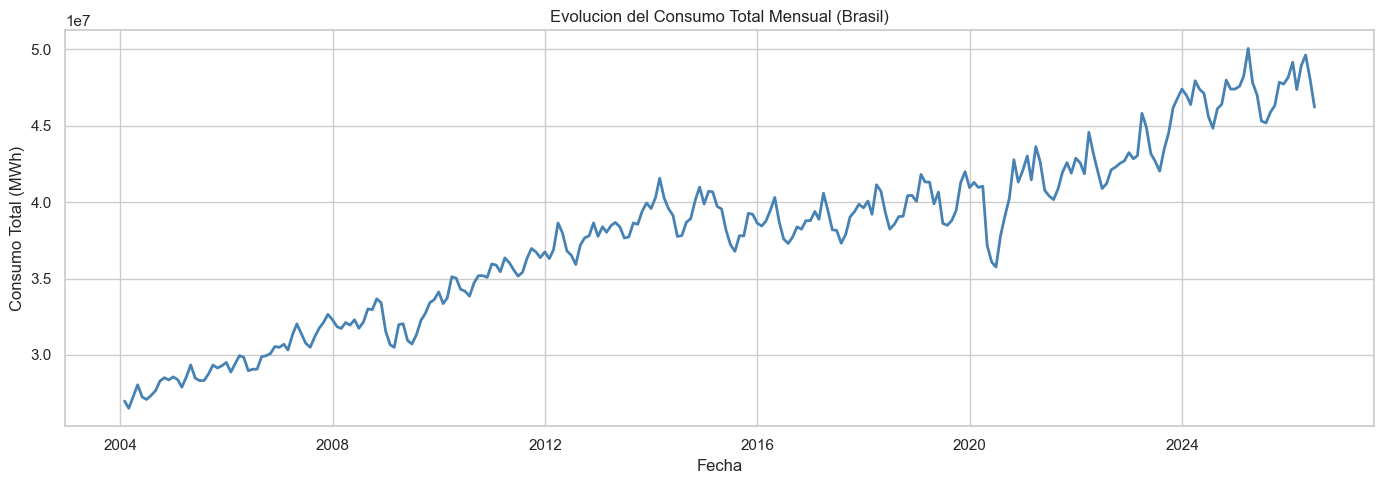

In [8]:
# Agrupar por fecha exacta y sumar el consumo de todos los registros de ese dia
consumo_total = df.groupby(df.index)['Consumo'].sum()

# Resamplear la serie diaria a nivel mensual
consumo_mensual = consumo_total.resample('ME').mean()

plt.figure(figsize=(14, 5))

# Graficar la serie temporal: X = fechas, Y = consumo promedio mensual
plt.plot(consumo_mensual.index, consumo_mensual, color='steelblue', linewidth=2)


plt.title('Evolucion del Consumo Total Mensual (Brasil)')
plt.xlabel('Fecha')
plt.ylabel('Consumo Total (MWh)')

plt.tight_layout()
plt.show()

**Hallazgo:** el consumo total mensual describe una trayectoria ascendente en el largo plazo con fluctuaciones estacionales superpuestas. El resampleo mensual revela la senda de fondo sin el ruido de corto plazo.


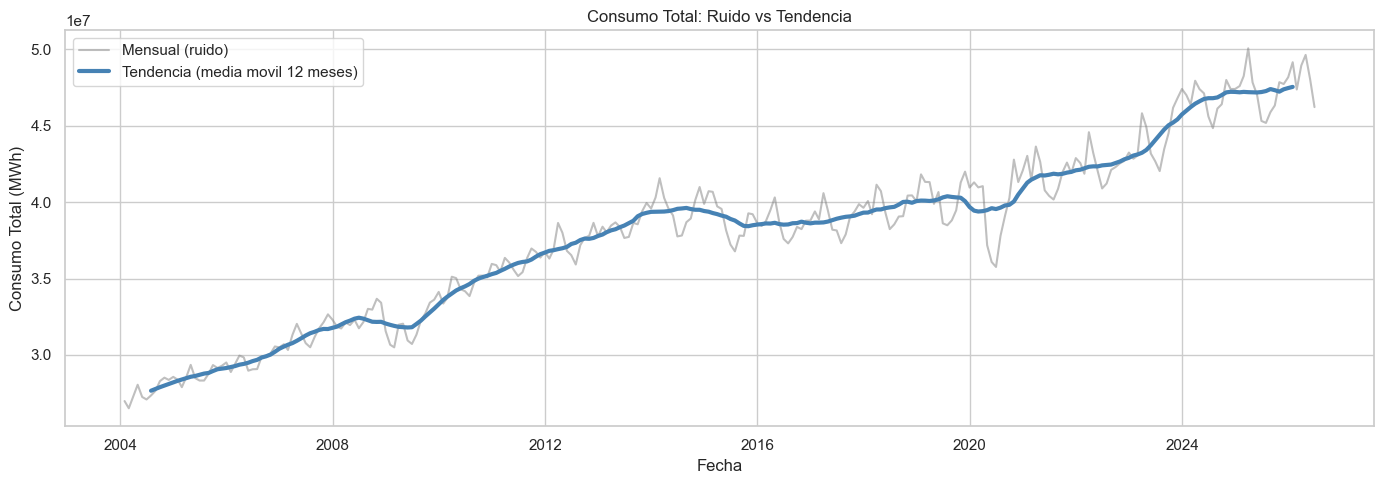

In [9]:
# Serie agregada por fecha: suma los registros (estados/classes) de cada mes
consumo_total = df.groupby(df.index)['Consumo'].sum()

# Consumo mensual: volatil y con estacionalidad => 'ruido' de corto plazo
# 'ME' agrupa por mes; con datos previamente mensuales coincide con el total
consumo_mensual = consumo_total.resample('ME').sum()

# Tendencia de largo plazo: media movil de 12 meses suaviza la estacionalidad
consumo_tendencia = consumo_mensual.rolling(12, center=True).mean()

plt.figure(figsize=(14, 5))
# Serie mensual en gris (volatilidad / ruido de corto plazo)
plt.plot(consumo_mensual.index, consumo_mensual, color='gray', alpha=0.5, label='Mensual (ruido)')
# Tendencia suavizada en azul y mas gruesa
plt.plot(consumo_tendencia.index, consumo_tendencia, color='steelblue', linewidth=3, label='Tendencia (media movil 12 meses)')
plt.title('Consumo Total: Ruido vs Tendencia')
plt.xlabel('Fecha')
plt.ylabel('Consumo Total (MWh)')
plt.legend()
plt.tight_layout()
plt.show()


**Hallazgo:** al superponer la serie diaria (ruido) y la mensual (tendencia) se confirma que el resampleo suaviza la volatilidad de corto plazo y expone la tendencia subyacente, claramente ascendente y con estacionalidad recurrente.


## 8. Análisis Bivariado Temporal: Consumo vs Consumidores
Evolución sincronizada de las dos variables principales en paneles compartiendo eje temporal.

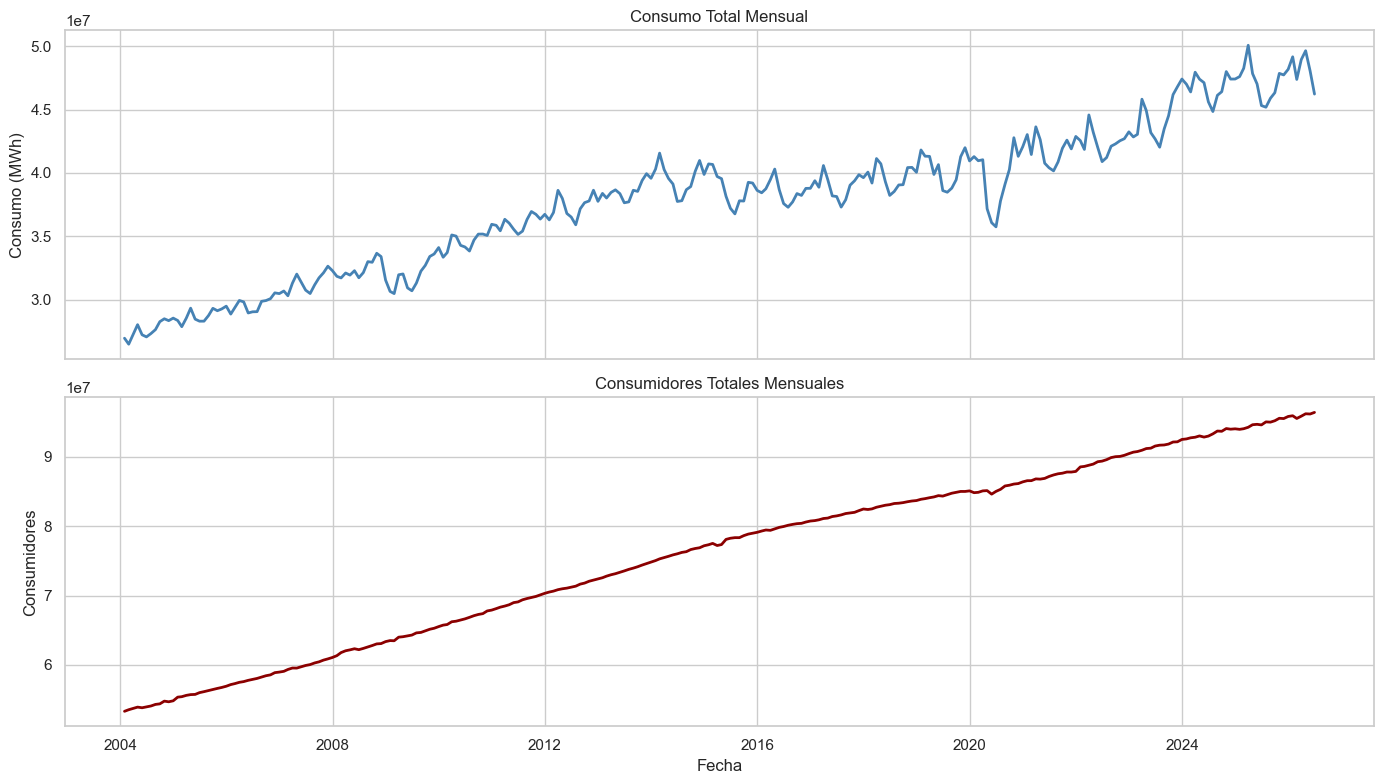

In [10]:
# Sumar el consumo por mes calendario
consumo_m = df['Consumo'].resample('ME').sum()

# Sumar el numero de consumidores por mes calendario
consumidores_m = df['Consumidores'].resample('ME').sum()

# Crear 2 subplots apilados verticalmente (2 filas, 1 columna)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel superior: evolucion del consumo total mensual
ax1.plot(consumo_m.index, consumo_m, color='steelblue', linewidth=2)
ax1.set_title('Consumo Total Mensual')
ax1.set_ylabel('Consumo (MWh)')

# Panel inferior: evolucion del numero de consumidores mensual
ax2.plot(consumidores_m.index, consumidores_m, color='darkred', linewidth=2)
ax2.set_title('Consumidores Totales Mensuales')
ax2.set_ylabel('Consumidores')
ax2.set_xlabel('Fecha')

# Ajustar el espaciado entre paneles
plt.tight_layout()
plt.show()

**Hallazgo:** consumo y consumidores evolucionan de forma sincronizada y creciente a lo largo del tiempo, lo que evidencia una relación directa: más consumidores implican más consumo. El crecimiento del parque de consumidores es el principal motor del aumento del consumo total.


## 9. Análisis por Región
Concentración de consumo por región, diferencias entre estados y composición por tipo de tensión.

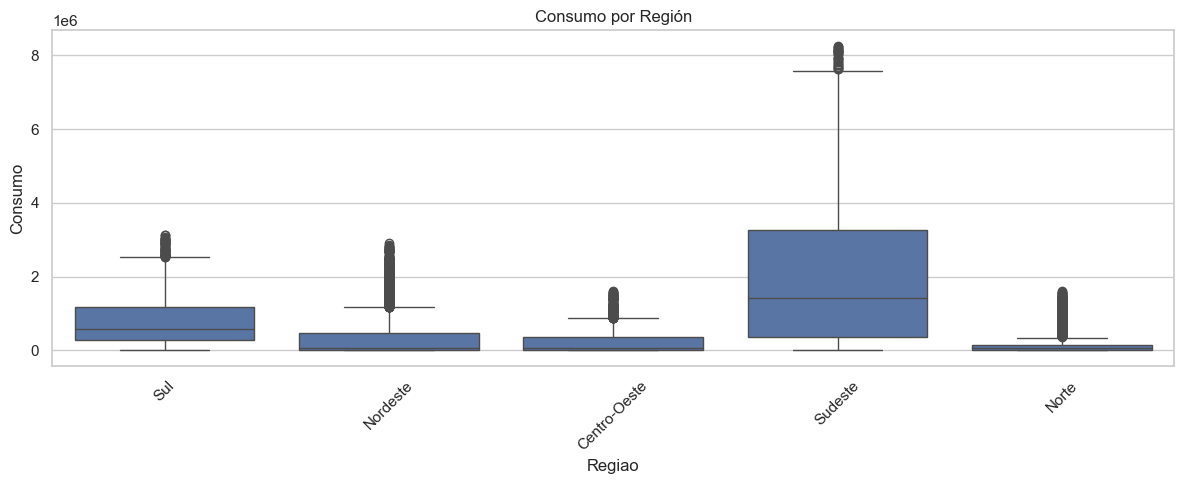

In [11]:
# Calcular el consumo total por region y quedarnos con las 5 de mayor consumo
top_regiao = df.groupby('Regiao')['Consumo'].sum().nlargest(5).index

# Filtrar el DataFrame para incluir solo las regiones 'top'
df_top = df[df['Regiao'].isin(top_regiao)]

plt.figure(figsize=(12, 5))
# Boxplot del consumo separado por region 
sns.boxplot(x='Regiao', y='Consumo', data=df_top)

plt.title('Consumo por Región')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Hallazgo:** la región Sudeste concentra el mayor consumo, seguida de Nordeste y Sul. La gran dispersión (bigotes y outliers) indica que dentro de cada región conviven registros de consumo muy distintos según sistema, clase y tipo de consumidor.


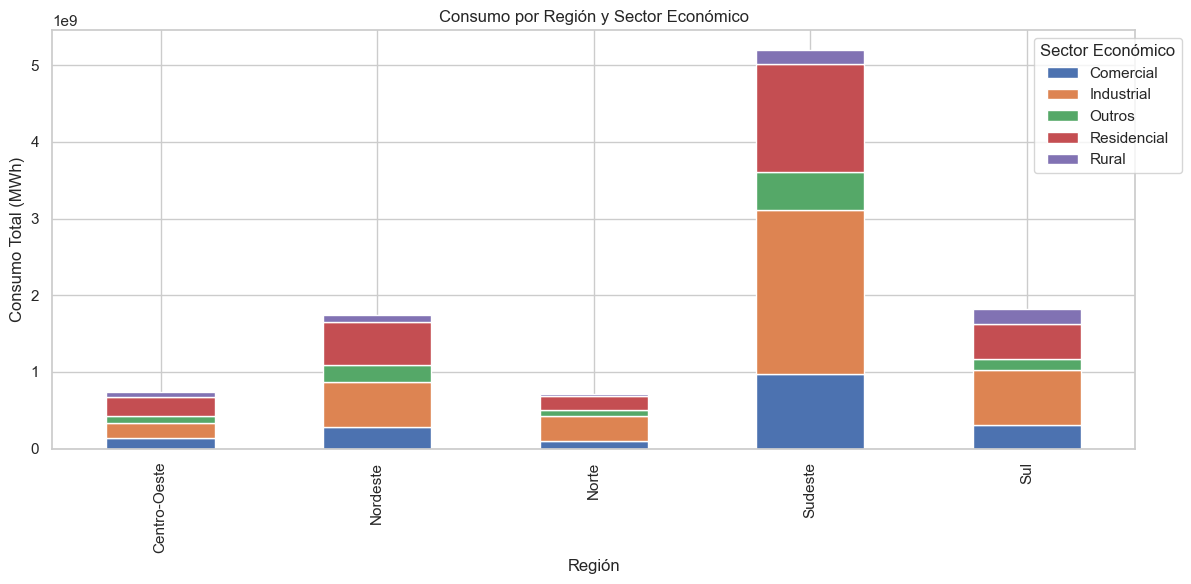

In [12]:
# Recalcular las 5 regiones con mayor consumo total (reutilizable)
top_regiao = df.groupby('Regiao')['Consumo'].sum().nlargest(5).index
# Filtrar el DataFrame a esas regiones top
df_top = df[df['Regiao'].isin(top_regiao)]

# Crear tabla pivote:
tabla = pd.pivot_table(df_top, values='Consumo', index='Regiao', columns='Classe', aggfunc='sum')

# Graficar la tabla como barras apiladas (stacked=True)
tabla.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title('Consumo por Región y Sector Económico')
plt.xlabel('Región')
plt.ylabel('Consumo Total (MWh)')
plt.legend(title='Sector Económico', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

**Hallazgo:** el consumo por región está dominado por los sectores Residencial e Industrial, aunque su participación varía entre regiones. La región Sudeste lidera el consumo en casi todos los sectores económicos.


## 10. Correlación y Regresión
Relación matemática entre consumidores y consumo, con heatmap de correlación y
regresión lineal para medir la fuerza del vínculo.

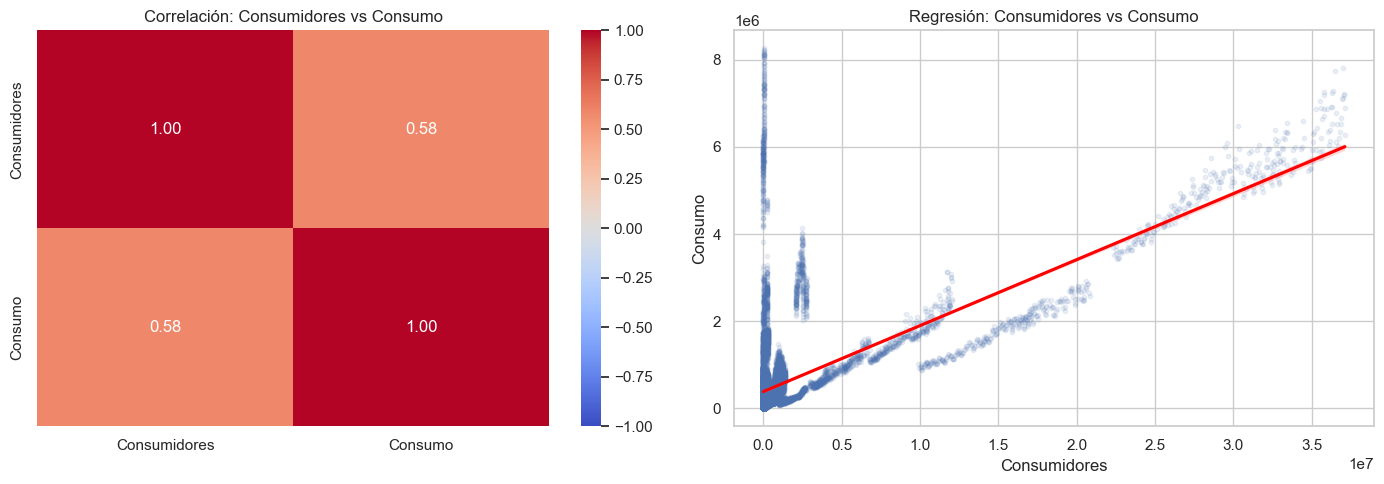

In [13]:
# Calcular la matriz de correlacion de Pearson entre las dos variables numericas
corr_matrix = df[['Consumidores', 'Consumo']].corr()

# Crear grilla de 1 fila x 2 columnas: heatmap (izq.) y regresion (der.)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dibujar el heatmap de la correlacion
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Correlación: Consumidores vs Consumo')

# Regresion lineal entre Consumidores y Consumo 
# line_kws configura la linea de regresion de minimos cuadrados en rojo
sns.regplot(x='Consumidores', y='Consumo', data=df, scatter_kws={'alpha': 0.1, 's': 10}, line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Regresión: Consumidores vs Consumo')

plt.tight_layout()
plt.show()

**Hallazgo:** existe una correlación positiva alta entre consumidores y consumo. La regresión lineal confirma la relación directa y coincide con la intuición económica de que más hogares o consumidores generan mayor demanda eléctrica.


## 11. Pairplot: Forma Visual de las Correlaciones
El pairplot complementa la matriz de correlación mostrando la distribución conjunta
de todas las variables numéricas.

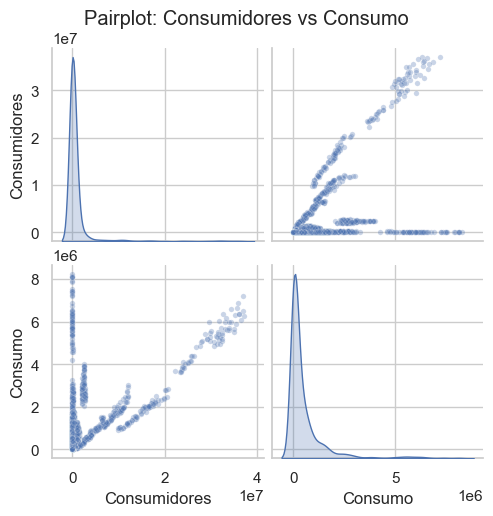

In [14]:
# Tomar una muestra aleatoria de 5000 filas para que el pairplot sea rapido
df_sample = df[['Consumidores', 'Consumo']].sample(n=min(5000, len(df)), random_state=42)

# pairplot genera una grilla NxN de scatter plots con todas las variables
# diag_kws={'fill': True} rellena las curvas de densidad con color
sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15},diag_kws={'fill': True})

# Agregar un titulo general sobre toda la grilla
plt.suptitle('Pairplot: Consumidores vs Consumo', y=1.02)
plt.show()

**Hallazgo:** el pairplot (sobre una muestra de 5,000 registros) confirma la relación lineal positiva entre consumidores y consumo, con una nube de puntos densa en valores bajos y mayor dispersión en el extremo superior (outliers de alto consumo).


## 12. Conclusiones del Análisis Exploratorio

1. **Dominancia de São Paulo**: concentra la mayor parte del consumo nacional, reflejando su peso económico y poblacional.
2. **Sesgo en la distribución**: la mayoría de los registros tienen valores bajos de consumo, con pocos registros de alto consumo que dominan el total.
3. **Estacionalidad regional**: los patrones de consumo varían entre estados del norte y del sureste, influenciados por el clima y la actividad económica.
4. **Crecimiento temporal**: la tendencia general es de aumento del consumo, reflejando el desarrollo económico del país.
5. **Cativo domina el mercado**: los consumidores regulados (Cativo) representan la vasta mayoría del consumo, aunque el segmento libre (Livre) crece.
6. **Correlación positiva**: existe una relación positiva entre la cantidad de consumidores y el consumo total, como era de esperarse.